<a href="https://colab.research.google.com/github/JosephAt10/PCVK_2026/blob/main/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**D. PRACTICAL**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Student_KTM.jpeg to Student_KTM.jpeg


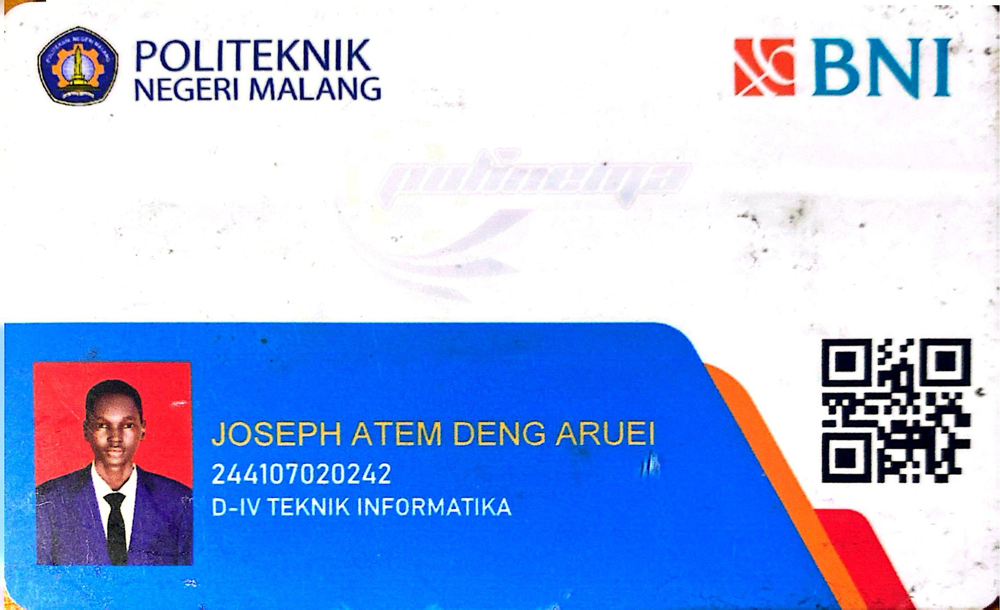

Resolusi gambar:  2268  x  1384


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('Student_KTM.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img. shape [1], " x ", img. shape [0])

Displaying Images

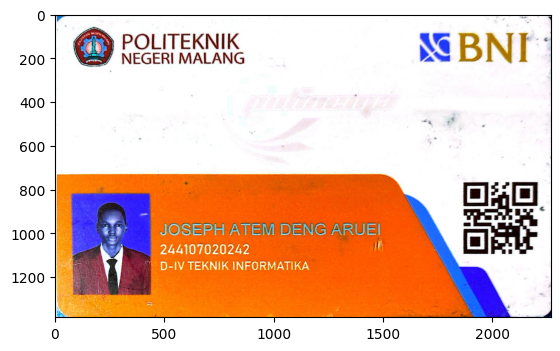

In [ ]:
img = cv.imread('Student_KTM.jpeg')
plt.imshow(img) #format warna BGR

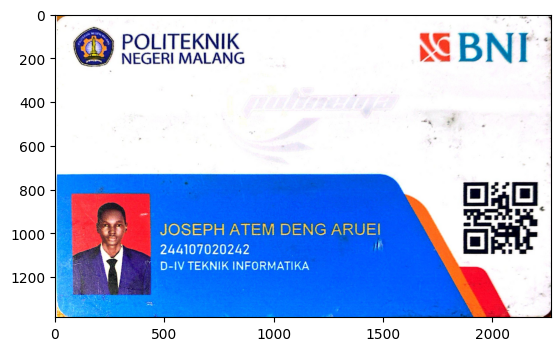

In [ ]:
img = cv.imread('Student_KTM.jpeg')
img2 = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img2)

Displaying Grayscale images

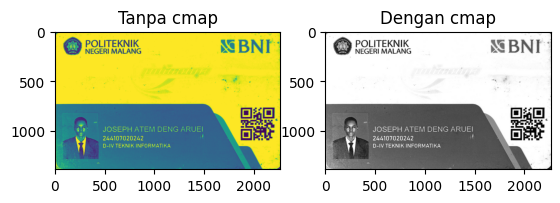

In [ ]:
img_gray = cv.imread('Student_KTM.jpeg', cv. IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt. subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

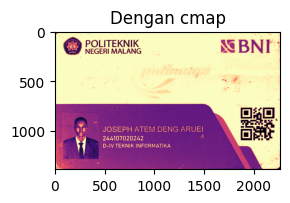

In [ ]:
img_gray = cv.imread('Student_KTM.jpeg', cv. IMREAD_GRAYSCALE)

# # Tanpa cmap
# plt.subplot(1,2,1)
# plt.imshow(img_gray)
# plt.title('Tanpa cmap')

# Dengan cmap
plt. subplot(1,2,2)
plt.imshow(img_gray, cmap='magma')
plt.title('Dengan cmap')

plt.show()

Resizing

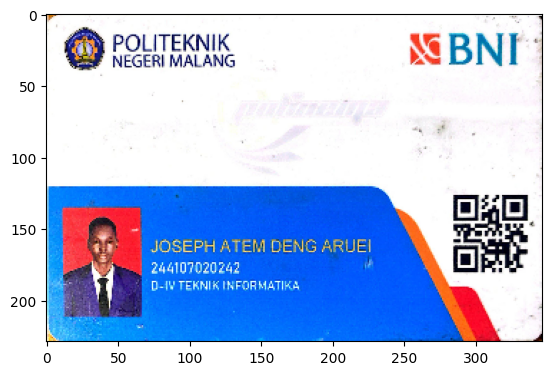

In [ ]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

Doing Flipping

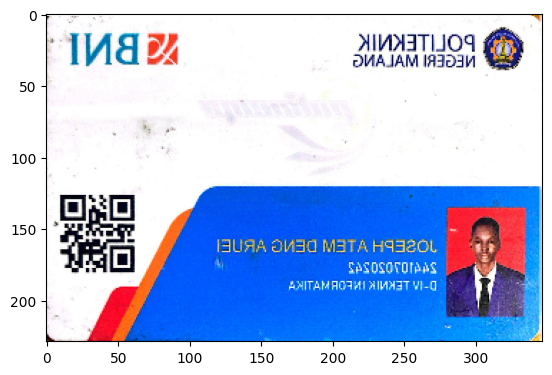

In [ ]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

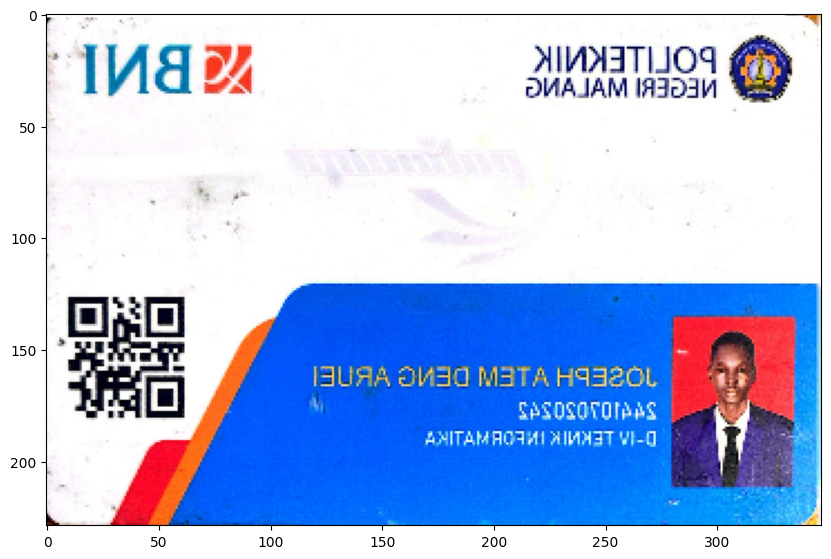

In [ ]:
imgFlip=cv.flip(img_output, 1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

6. Creating a 2D geometric shape

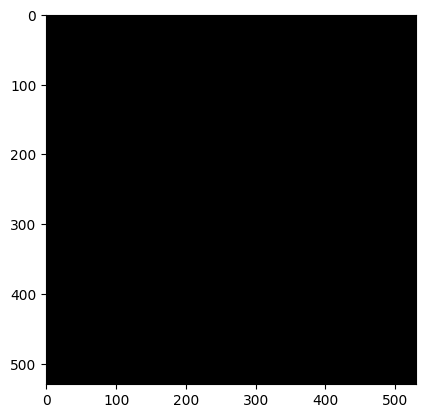

In [ ]:
black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

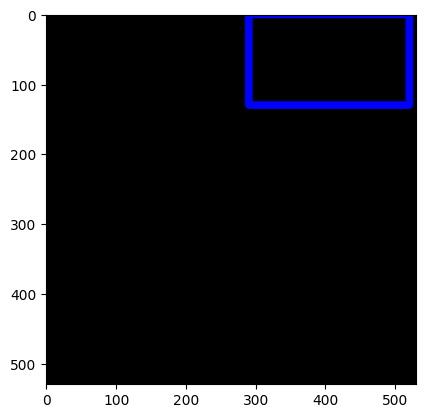

In [ ]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

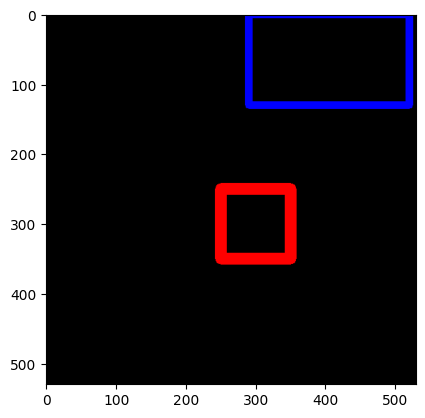

In [ ]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350), color=(255,0,0),thickness=15)
plt.imshow(black_img)

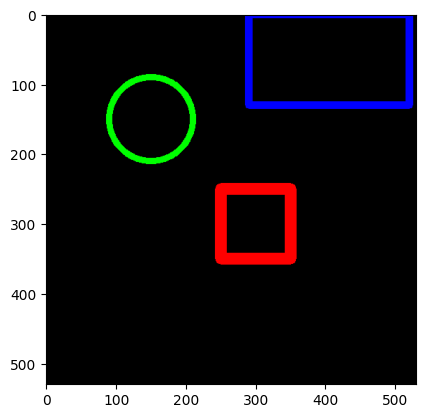

In [ ]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

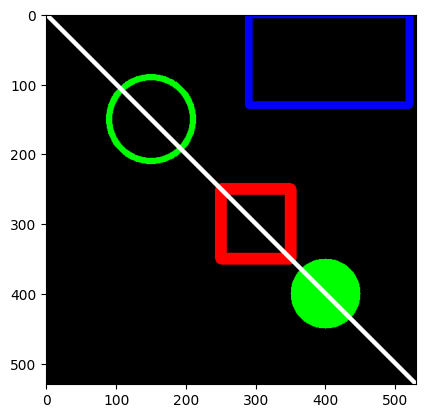

In [ ]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness =- 1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

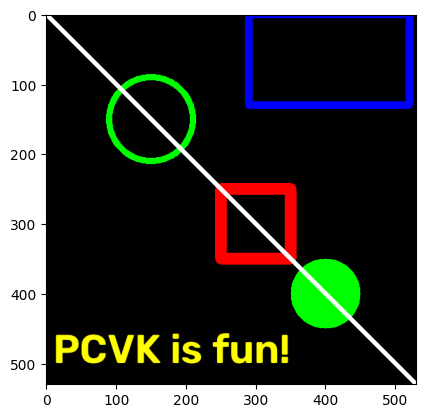

In [ ]:
black_img = black_img.astype(np.uint8)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

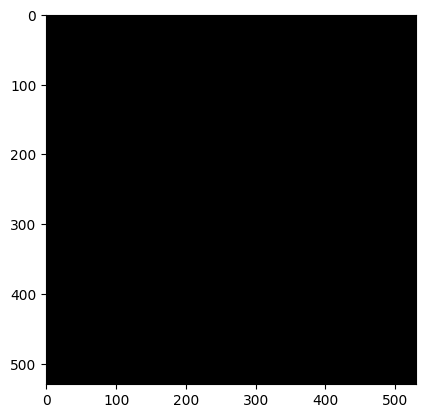

In [ ]:
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

In [ ]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [ ]:
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

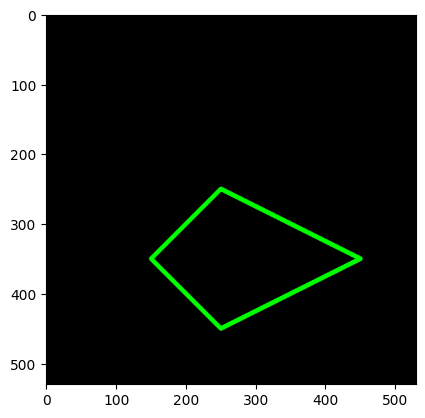

In [ ]:
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

In [1]:
from google.colab import files
from google.colab.patches import cv2_imshow

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

uploaded = files.upload()  # Upload ONE main image
MAIN_IMAGE_PATH = "/content/" + next(iter(uploaded))

img_bgr = cv2.imread(MAIN_IMAGE_PATH, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise ValueError("Image could not be read.")

h, w = img_bgr.shape[:2]
print("Image shape:", img_bgr.shape)
print("Image dtype:", img_bgr.dtype)

Saving Student_KTM.jpeg to Student_KTM.jpeg
Image shape: (1384, 2268, 3)
Image dtype: uint8


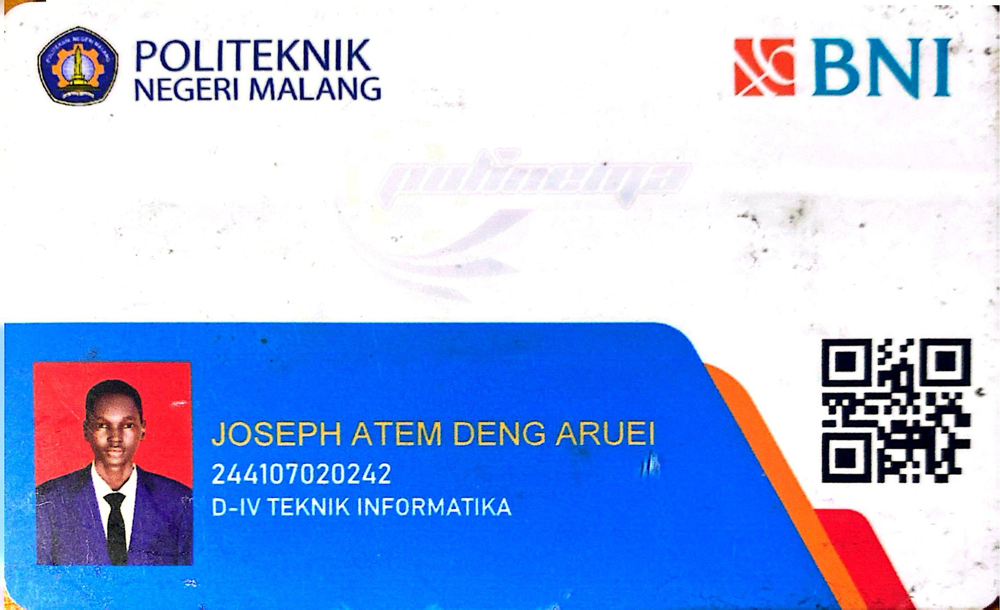

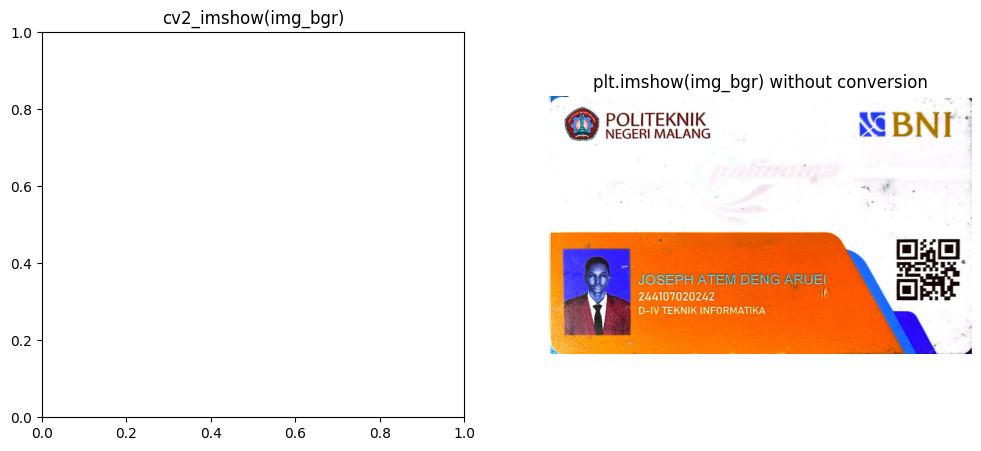

Selected pixel coordinate [y, x]: [np.int64(151), np.int64(229)]
cv2.imread() pixel value (BGR): [  0 147 255]
plt.imread() pixel value (RGB): [255 147   0]
cv2 pixel reversed to RGB: [255 147   0]

Conclusion:
cv2_imshow understands OpenCV BGR data, while plt.imshow assumes RGB.
Therefore, plt.imshow(img_bgr) swaps the apparent red and blue colors.


In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cv2_imshow(img_bgr)
plt.title("cv2_imshow(img_bgr)")

plt.subplot(1, 2, 2)
plt.imshow(img_bgr)  # Intentionally no BGR-to-RGB conversion
plt.title("plt.imshow(img_bgr) without conversion")
plt.axis("off")

plt.show()

# Select a pixel where red and blue differ the most
difference = np.abs(
    img_bgr[:, :, 2].astype(np.int16) - img_bgr[:, :, 0].astype(np.int16)
)
y, x = np.unravel_index(np.argmax(difference), difference.shape)

img_mpl = plt.imread(MAIN_IMAGE_PATH)
if img_mpl.ndim == 3 and img_mpl.shape[2] == 4:
    img_mpl = img_mpl[:, :, :3]

if np.issubdtype(img_mpl.dtype, np.floating):
    img_mpl_8bit = np.rint(img_mpl * 255).astype(np.uint8)
else:
    img_mpl_8bit = img_mpl.astype(np.uint8)

print("Selected pixel coordinate [y, x]:", [y, x])
print("cv2.imread() pixel value (BGR):", img_bgr[y, x])
print("plt.imread() pixel value (RGB):", img_mpl_8bit[y, x])
print("cv2 pixel reversed to RGB:", img_bgr[y, x][::-1])
print("\nConclusion:")
print("cv2_imshow understands OpenCV BGR data, while plt.imshow assumes RGB.")
print("Therefore, plt.imshow(img_bgr) swaps the apparent red and blue colors.")


int16 canvas
dtype : int16
min() : 0
max() : 0
nbytes: 18833472 bytes

int32 canvas
dtype : int32
min() : 0
max() : 0
nbytes: 37666944 bytes


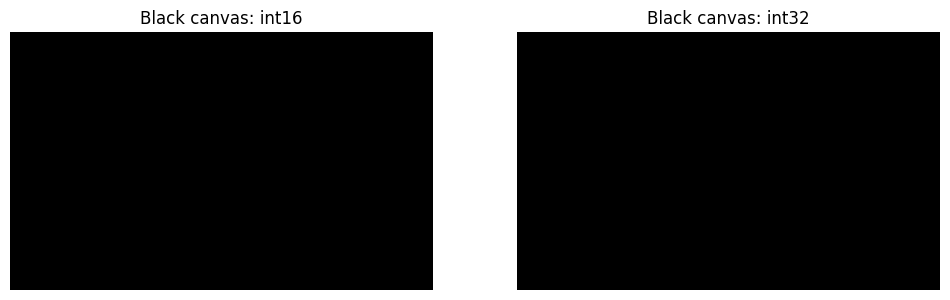


Conclusion:
Both canvases appear black because every pixel value is 0.
int32 uses twice as much memory as int16 because int32 stores 4 bytes per value,
while int16 stores 2 bytes per value.


In [3]:
canvas_int16 = np.zeros((h, w, 3), dtype=np.int16)
canvas_int32 = np.zeros((h, w, 3), dtype=np.int32)

for name, canvas in {
    "int16 canvas": canvas_int16,
    "int32 canvas": canvas_int32
}.items():
    print(f"\n{name}")
    print("dtype :", canvas.dtype)
    print("min() :", canvas.min())
    print("max() :", canvas.max())
    print("nbytes:", canvas.nbytes, "bytes")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(canvas_int16)
plt.title("Black canvas: int16")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canvas_int32)
plt.title("Black canvas: int32")
plt.axis("off")

plt.show()

print("\nConclusion:")
print("Both canvases appear black because every pixel value is 0.")
print("int32 uses twice as much memory as int16 because int32 stores 4 bytes per value,")
print("while int16 stores 2 bytes per value.")

In [4]:
print("google.colab.patches.cv2_imshow is a Colab-compatible replacement for cv2.imshow().")
print("cv2.imshow() requires an operating-system GUI window (OpenCV HighGUI).")
print("Google Colab runs in a remote server environment without a desktop GUI window,")
print("so cv2.imshow() cannot display images there.")

google.colab.patches.cv2_imshow is a Colab-compatible replacement for cv2.imshow().
cv2.imshow() requires an operating-system GUI window (OpenCV HighGUI).
Google Colab runs in a remote server environment without a desktop GUI window,
so cv2.imshow() cannot display images there.


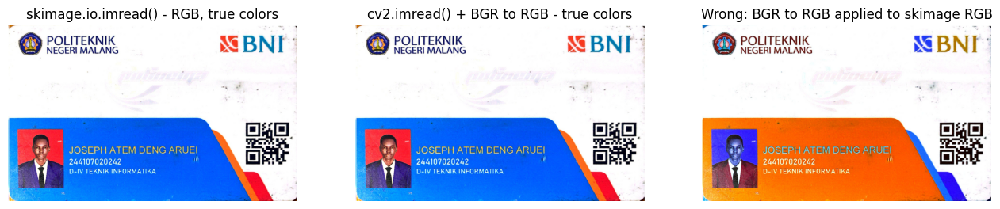

Selected pixel coordinate [y, x]: [np.int64(151), np.int64(229)]
skimage RGB pixel: [255 147   0]
OpenCV BGR converted to RGB pixel: [255 147   0]
Wrongly converted skimage pixel: [  0 147 255]

Verification:
skimage RGB equals converted OpenCV RGB: True
Wrong conversion equals reversed skimage channels: True

Conclusion:
skimage.io.imread() already produces true RGB colors.
cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) also produces true RGB colors.
Applying COLOR_BGR2RGB to an image already read by skimage swaps red and blue.


In [5]:
img_sk_rgb = io.imread(MAIN_IMAGE_PATH)

if img_sk_rgb.ndim == 3 and img_sk_rgb.shape[2] == 4:
    img_sk_rgb = img_sk_rgb[:, :, :3]

img_cv_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# This conversion is intentionally wrong because skimage already uses RGB.
img_sk_wrong = cv2.cvtColor(img_sk_rgb, cv2.COLOR_BGR2RGB)

difference = np.abs(
    img_sk_rgb[:, :, 0].astype(np.int16) -
    img_sk_rgb[:, :, 2].astype(np.int16)
)
y, x = np.unravel_index(np.argmax(difference), difference.shape)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_sk_rgb)
plt.title("skimage.io.imread() - RGB, true colors")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_cv_rgb)
plt.title("cv2.imread() + BGR to RGB - true colors")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_sk_wrong)
plt.title("Wrong: BGR to RGB applied to skimage RGB")
plt.axis("off")

plt.show()

print("Selected pixel coordinate [y, x]:", [y, x])
print("skimage RGB pixel:", img_sk_rgb[y, x])
print("OpenCV BGR converted to RGB pixel:", img_cv_rgb[y, x])
print("Wrongly converted skimage pixel:", img_sk_wrong[y, x])

print("\nVerification:")
print("skimage RGB equals converted OpenCV RGB:",
      np.array_equal(img_sk_rgb, img_cv_rgb))
print("Wrong conversion equals reversed skimage channels:",
      np.array_equal(img_sk_wrong[y, x], img_sk_rgb[y, x][::-1]))

print("\nConclusion:")
print("skimage.io.imread() already produces true RGB colors.")
print("cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) also produces true RGB colors.")
print("Applying COLOR_BGR2RGB to an image already read by skimage swaps red and blue.")

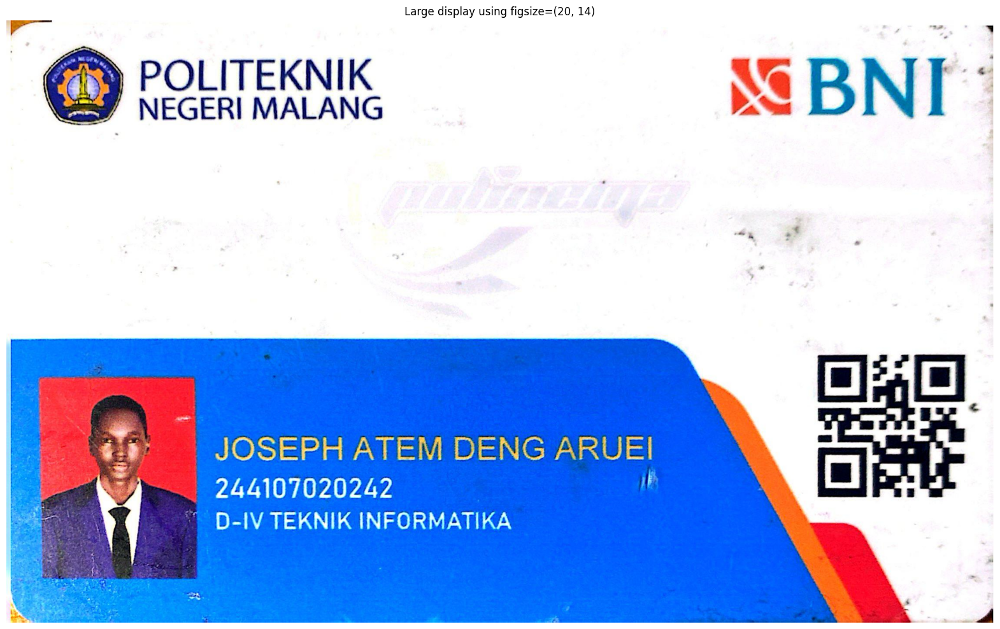

img.shape before display: (1384, 2268, 3)
img.shape after display : (1384, 2268, 3)
Shape changed: False

Conclusion:
figsize changes only the display canvas size in Matplotlib.
It does not change the number of pixels in the image array.
cv2.resize() changes the actual image resolution and img.shape.


In [6]:
shape_before = img_bgr.shape

plt.figure(figsize=(20, 14))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Large display using figsize=(20, 14)")
plt.axis("off")
plt.show()

shape_after = img_bgr.shape

print("img.shape before display:", shape_before)
print("img.shape after display :", shape_after)
print("Shape changed:", shape_before != shape_after)

print("\nConclusion:")
print("figsize changes only the display canvas size in Matplotlib.")
print("It does not change the number of pixels in the image array.")
print("cv2.resize() changes the actual image resolution and img.shape.")

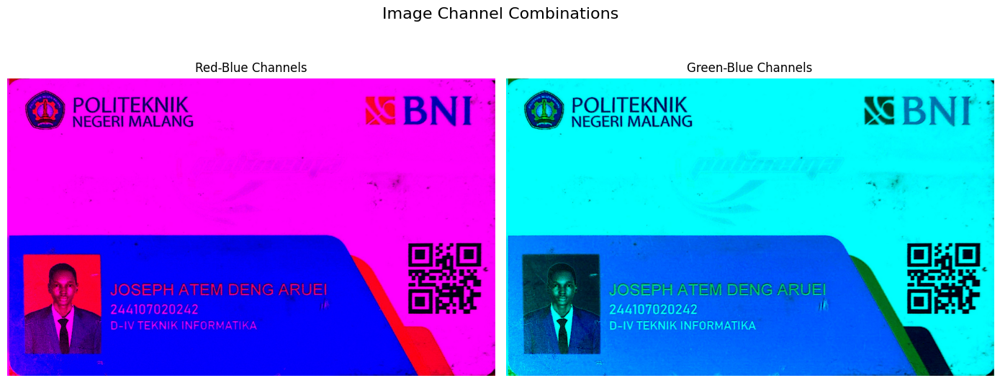

In [7]:
red_blue_bgr = img_bgr.copy()
red_blue_bgr[:, :, 1] = 0  # Remove Green

green_blue_bgr = img_bgr.copy()
green_blue_bgr[:, :, 2] = 0  # Remove Red

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(red_blue_bgr, cv2.COLOR_BGR2RGB))
plt.title("Red-Blue Channels")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(green_blue_bgr, cv2.COLOR_BGR2RGB))
plt.title("Green-Blue Channels")
plt.axis("off")

plt.suptitle("Image Channel Combinations", fontsize=16)
plt.tight_layout()
plt.show()

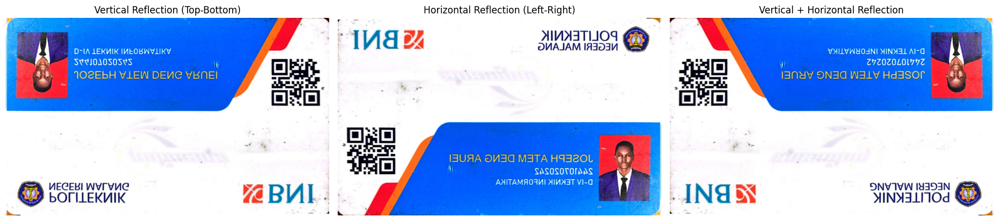

In [8]:
vertical_flip = cv2.flip(img_bgr, 0)
horizontal_flip = cv2.flip(img_bgr, 1)
both_flip = cv2.flip(img_bgr, -1)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(vertical_flip, cv2.COLOR_BGR2RGB))
plt.title("Vertical Reflection (Top-Bottom)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(horizontal_flip, cv2.COLOR_BGR2RGB))
plt.title("Horizontal Reflection (Left-Right)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(both_flip, cv2.COLOR_BGR2RGB))
plt.title("Vertical + Horizontal Reflection")
plt.axis("off")

plt.tight_layout()
plt.show()

Saving josep.jpeg to josep.jpeg


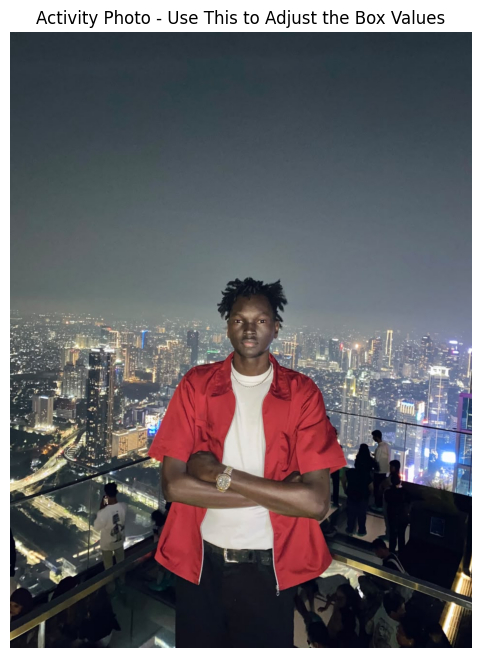

In [9]:
uploaded_activity = files.upload()
ACTIVITY_IMAGE_PATH = "/content/" + next(iter(uploaded_activity))

activity_bgr = cv2.imread(ACTIVITY_IMAGE_PATH, cv2.IMREAD_COLOR)

if activity_bgr is None:
    raise ValueError("Activity image could not be read.")

ah, aw = activity_bgr.shape[:2]

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(activity_bgr, cv2.COLOR_BGR2RGB))
plt.title("Activity Photo - Use This to Adjust the Box Values")
plt.axis("off")
plt.show()

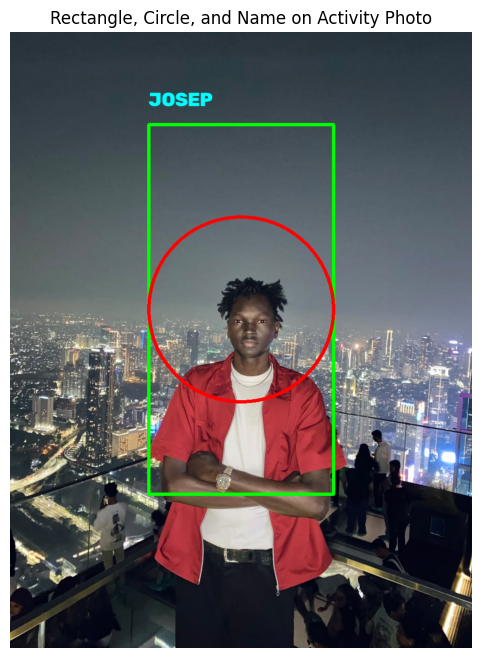

In [11]:
NAME = "JOSEP"

# Normalized coordinates: 0.0 to 1.0
BOX_LEFT = 0.30
BOX_TOP = 0.15
BOX_RIGHT = 0.70
BOX_BOTTOM = 0.75

x1 = int(BOX_LEFT * aw)
y1 = int(BOX_TOP * ah)
x2 = int(BOX_RIGHT * aw)
y2 = int(BOX_BOTTOM * ah)

result_bgr = activity_bgr.copy()

thickness = max(1, int(min(ah, aw) / 180))
font_scale = min(ah, aw) / 700
rectangle_color = (0, 255, 0)  # Green in BGR
circle_color = (0, 0, 255)     # Red in BGR
text_color = (255, 255, 0)     # Cyan in BGR

cv2.rectangle(result_bgr, (x1, y1), (x2, y2), rectangle_color, thickness)

center_x = (x1 + x2) // 2
center_y = (y1 + y2) // 2
radius = max(1, min(x2 - x1, y2 - y1) // 2)

cv2.circle(result_bgr, (center_x, center_y), radius, circle_color, thickness)

text_y = max(int(0.06 * ah), y1 - int(0.03 * ah))
cv2.putText(
    result_bgr,
    NAME,
    (x1, text_y),
    cv2.FONT_HERSHEY_DUPLEX,
    font_scale,
    text_color,
    thickness,
    cv2.LINE_AA
)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB))
plt.title("Rectangle, Circle, and Name on Activity Photo")
plt.axis("off")
plt.show()

QUESTION:
What percentage of pixels in the image are darker than 100?

PROGRAM DESIGN:
1. Convert the BGR image to grayscale.
2. Count pixels with intensity lower than 100.
3. Divide dark-pixel count by total-pixel count.

RESULTING DATA:
Image size: (1384, 2268)
Total pixels: 3138912
Pixels darker than 100: 973499
Percentage of dark pixels: 31.01%

CONCLUSION:
Less than half of the image pixels are dark.


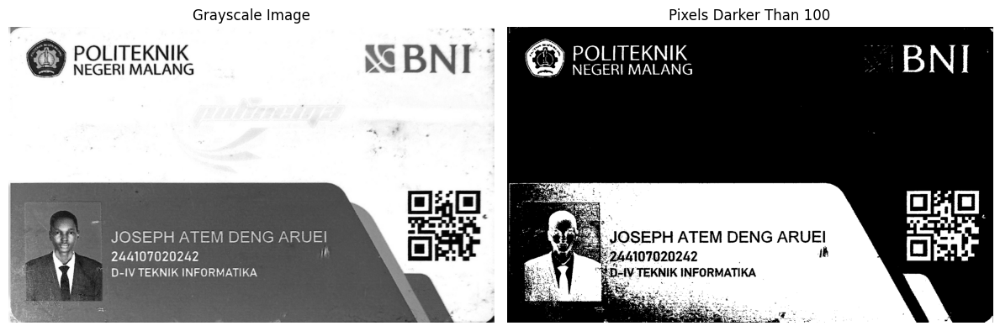

In [12]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

dark_threshold = 100
dark_pixels = np.sum(gray < dark_threshold)
total_pixels = gray.size
dark_percentage = (dark_pixels / total_pixels) * 100

print("QUESTION:")
print(f"What percentage of pixels in the image are darker than {dark_threshold}?")

print("\nPROGRAM DESIGN:")
print("1. Convert the BGR image to grayscale.")
print("2. Count pixels with intensity lower than 100.")
print("3. Divide dark-pixel count by total-pixel count.")

print("\nRESULTING DATA:")
print("Image size:", gray.shape)
print("Total pixels:", total_pixels)
print(f"Pixels darker than {dark_threshold}:", dark_pixels)
print(f"Percentage of dark pixels: {dark_percentage:.2f}%")

print("\nCONCLUSION:")
if dark_percentage >= 50:
    print("More than half of the image pixels are dark.")
else:
    print("Less than half of the image pixels are dark.")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray < dark_threshold, cmap="gray")
plt.title(f"Pixels Darker Than {dark_threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

Saving case1.2.jpg to case1.2.jpg
Saving case1.jpg to case1 (1).jpg


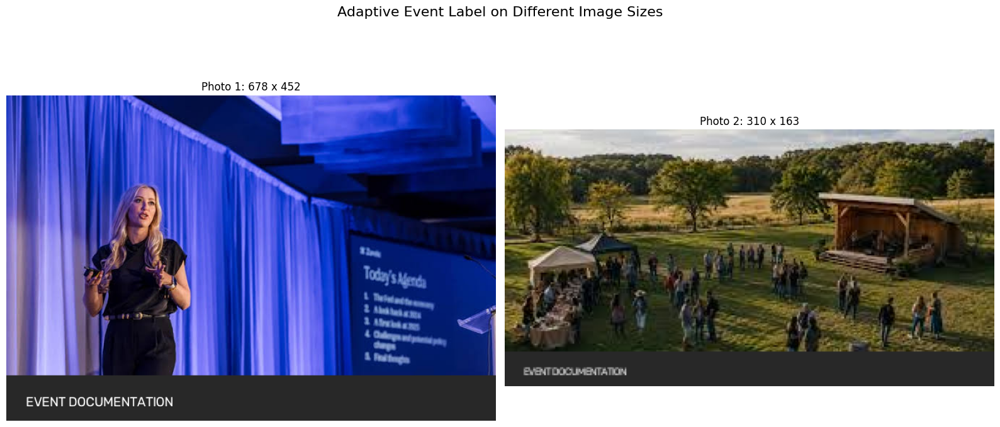

In [14]:
uploaded_event = files.upload()

event_paths = ["/content/" + name for name in uploaded_event.keys()]

if len(event_paths) < 2:
    raise ValueError("Upload at least two event photos with different sizes.")

EVENT_LABEL = "EVENT DOCUMENTATION"

def add_event_label(image_bgr, label):
    h, w = image_bgr.shape[:2]
    result = image_bgr.copy()

    bar_height = max(1, int(0.14 * h))
    padding_x = max(1, int(0.04 * w))
    thickness = max(1, int(min(h, w) / 300))
    font_scale = min(h, w) / 700

    cv2.rectangle(
        result,
        (0, h - bar_height),
        (w, h),
        (40, 40, 40),
        -1
    )

    text_y = h - int(0.32 * bar_height)

    cv2.putText(
        result,
        label,
        (padding_x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

    return result

event_1 = cv2.imread(event_paths[0], cv2.IMREAD_COLOR)
event_2 = cv2.imread(event_paths[1], cv2.IMREAD_COLOR)

event_1_labeled = add_event_label(event_1, EVENT_LABEL)
event_2_labeled = add_event_label(event_2, EVENT_LABEL)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(event_1_labeled, cv2.COLOR_BGR2RGB))
plt.title(f"Photo 1: {event_1.shape[1]} x {event_1.shape[0]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(event_2_labeled, cv2.COLOR_BGR2RGB))
plt.title(f"Photo 2: {event_2.shape[1]} x {event_2.shape[0]}")
plt.axis("off")

plt.suptitle("Adaptive Event Label on Different Image Sizes", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
uploaded_product = files.upload()
PRODUCT_IMAGE_PATH = "/content/" + next(iter(uploaded_product))

product_bgr = cv2.imread(PRODUCT_IMAGE_PATH, cv2.IMREAD_COLOR)

if product_bgr is None:
    raise ValueError("Product image could not be read.")

Saving case2.jpg to case2 (1).jpg


In [17]:
uploaded_logo = files.upload()
LOGO_IMAGE_PATH = "/content/" + next(iter(uploaded_logo))

logo = cv2.imread(LOGO_IMAGE_PATH, cv2.IMREAD_UNCHANGED)

if logo is None:
    raise ValueError("Logo image could not be read.")

Saving case2.2.jpg to case2.2 (1).jpg


Original product size: (554, 554)
Square thumbnail size: (554, 554)


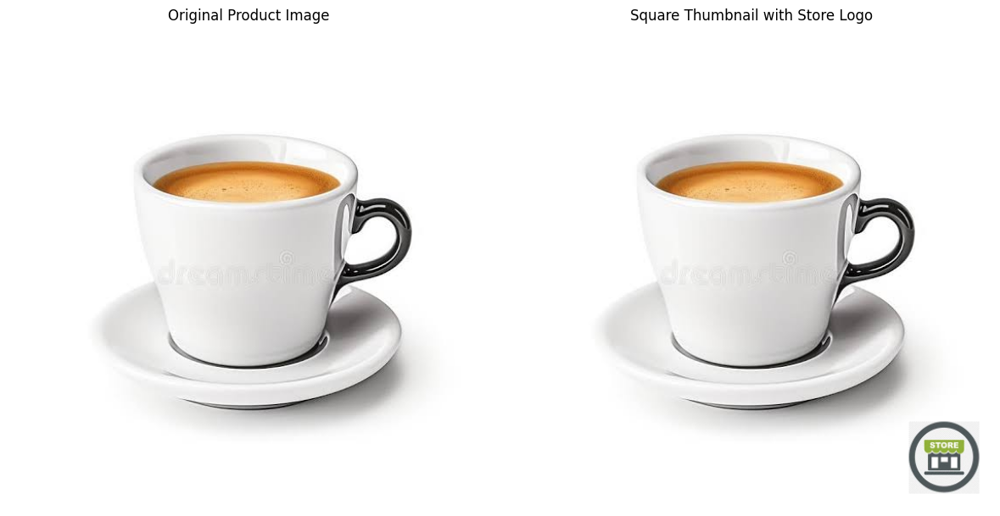

In [18]:
def make_square_thumbnail(product_bgr, logo_image):
    h, w = product_bgr.shape[:2]
    side = max(h, w)

    background_color = (255, 240, 220)  # BGR
    thumbnail = np.full((side, side, 3), background_color, dtype=np.uint8)

    scale = side / max(h, w)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    product_resized = cv2.resize(
        product_bgr,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    x_offset = (side - new_w) // 2
    y_offset = (side - new_h) // 2

    thumbnail[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = product_resized

    if logo_image.ndim == 2:
        logo_bgr = cv2.cvtColor(logo_image, cv2.COLOR_GRAY2BGR)
        alpha = None
    elif logo_image.shape[2] == 4:
        logo_bgr = logo_image[:, :, :3]
        alpha = logo_image[:, :, 3]
    else:
        logo_bgr = logo_image
        alpha = None

    logo_h, logo_w = logo_bgr.shape[:2]

    max_logo_w = max(1, int(0.20 * side))
    max_logo_h = max(1, int(0.15 * side))

    logo_scale = min(max_logo_w / logo_w, max_logo_h / logo_h)
    resized_logo_w = max(1, int(logo_w * logo_scale))
    resized_logo_h = max(1, int(logo_h * logo_scale))

    logo_resized = cv2.resize(
        logo_bgr,
        (resized_logo_w, resized_logo_h),
        interpolation=cv2.INTER_AREA
    )

    padding = max(1, int(0.03 * side))
    logo_x = side - resized_logo_w - padding
    logo_y = side - resized_logo_h - padding

    roi = thumbnail[
        logo_y:logo_y + resized_logo_h,
        logo_x:logo_x + resized_logo_w
    ]

    if alpha is None:
        roi[:] = logo_resized
    else:
        alpha_resized = cv2.resize(
            alpha,
            (resized_logo_w, resized_logo_h),
            interpolation=cv2.INTER_AREA
        )

        alpha_normalized = alpha_resized.astype(np.float32) / 255.0

        for channel in range(3):
            roi[:, :, channel] = (
                alpha_normalized * logo_resized[:, :, channel] +
                (1 - alpha_normalized) * roi[:, :, channel]
            ).astype(np.uint8)

    return thumbnail

thumbnail_bgr = make_square_thumbnail(product_bgr, logo)

print("Original product size:", product_bgr.shape[:2])
print("Square thumbnail size:", thumbnail_bgr.shape[:2])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(product_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Product Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(thumbnail_bgr, cv2.COLOR_BGR2RGB))
plt.title("Square Thumbnail with Store Logo")
plt.axis("off")

plt.tight_layout()
plt.show()